# FairLoan: catch it, fix it, prove it
**Run in Google Colab or Kaggle.** Upload this whole folder (or `git clone` your repo), then Run all. Data: `data/india_credit.csv` (see DATA_CARD.md).
The heavy lifting lives in `pipeline.py` so the notebook, the dashboard and the pitch all show the same numbers.

In [1]:
!pip -q install fairlearn  # Colab already has pandas / scikit-learn / matplotlib
# If you cloned a repo: %cd your-repo-name

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pipeline as pl
df = pl.load_data()
print(df.shape, '| share of women:', round(df.female.mean(), 2))
print('Truly good loans - men:', round(df[df.female==0].credit_risk.mean(), 2), ' women:', round(df[df.female==1].credit_risk.mean(), 2))

(601, 13) | share of women: 0.19
Truly good loans - men: 0.69  women: 0.67


## 0. Recreate the problem: a biased history
We corrupt **only the training labels**: 30% of women who really repaid get recorded as defaults. Test labels stay clean, so we know the truth.

In [3]:
m = pl.FairLoanModels(seed=pl.SHOWCASE_SEED, bias=pl.DEFAULT_BIAS).fit()
flipped = (m.ytr_biased != m.ytr_true).sum()
print(f'{flipped} training labels flipped')
print('Recorded "good" rate in training - men:', m.ytr_biased[m.atr==0].mean().round(2), ' women:', m.ytr_biased[m.atr==1].mean().round(2))
print('TRUE "good" rate in training     - men:', m.ytr_true[m.atr==0].mean().round(2),  ' women:', m.ytr_true[m.atr==1].mean().round(2))

16 training labels flipped
Recorded "good" rate in training - men: 0.69  women: 0.46
TRUE "good" rate in training     - men: 0.69  women: 0.67


## 1. CATCH it
An ordinary logistic regression trained on that history. Everything is measured against the *true* test labels.

In [4]:
res = pl.evaluate_all(m)
b = res['Baseline']
print(pd.DataFrame(b['by_group']).T.round(3))
print()
print('Approval gap (men - women):        ', round(b['approval_gap'], 3))
print('Equal-opportunity gap (qualified): ', round(b['equal_opportunity_gap'], 3))
print('Fairlearn demographic parity diff: ', round(b['demographic_parity_difference'], 3))
print('Fairlearn equalized odds diff:     ', round(b['equalized_odds_difference'], 3))

        approval_rate    tpr    fpr
Male            0.823  0.990  0.444
Female          0.500  0.652  0.182

Approval gap (men - women):         0.323
Equal-opportunity gap (qualified):  0.338
Fairlearn demographic parity diff:  0.323
Fairlearn equalized odds diff:      0.338


In [5]:
# Single splits are noisy with only 300 test rows - average 20 random splits
ms = pl.multi_seed(0.30, range(20))
pd.DataFrame(ms['mean']).T[['accuracy','male_approval','female_approval','male_tpr','female_tpr','approval_gap','equal_opportunity_gap']].round(3)

,accuracy,male_approval,female_approval,male_tpr,female_tpr,approval_gap,equal_opportunity_gap
Baseline,0.781,0.863,0.572,0.977,0.704,0.291,0.273
Baseline without gender column,0.802,0.859,0.826,0.974,0.974,0.033,0.000
Fixed (Fairlearn),0.793,0.840,0.816,0.955,0.952,0.024,0.003
Reference (trained on fair labels),0.802,0.863,0.837,0.978,0.983,0.026,-0.005


## 2. FIX it
Fairlearn `ThresholdOptimizer` (demographic parity) on top of the *same* trained model.

In [6]:
print('Learned cut-offs on repay-probability:', m.thresholds())
f = res['Fixed (Fairlearn)']
print(pd.DataFrame(f['by_group']).T.round(3))
print('Accuracy  baseline -> fixed:', round(b['accuracy'],3), '->', round(f['accuracy'],3))
print('Approval gap  ->', round(f['approval_gap'],3), '| qualified gap ->', round(f['equal_opportunity_gap'],3))

Learned cut-offs on repay-probability: {'male': 0.629, 'female': 0.351}
        approval_rate    tpr    fpr
Male            0.796  0.961  0.422
Female          0.765  0.913  0.455
Accuracy  baseline -> fixed: 0.829 -> 0.834
Approval gap  -> 0.031 | qualified gap -> 0.048


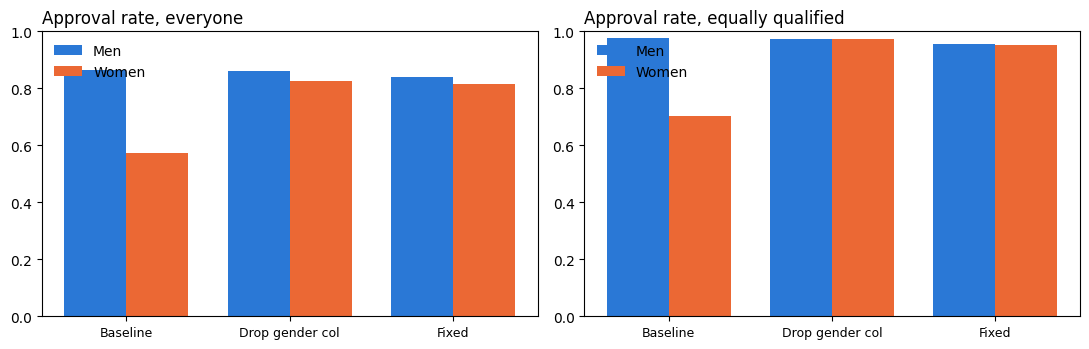

In [7]:
names = ['Baseline', 'Baseline without gender column', 'Fixed (Fairlearn)']
x = np.arange(3); w = .38
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, key, ttl in zip(ax, ['approval_rate', 'tpr'], ['Approval rate, everyone', 'Approval rate, equally qualified']):
    a.bar(x - w/2, [ms['mean'][n]['male_approval' if key=='approval_rate' else 'male_tpr'] for n in names], w, color='#2a78d6', label='Men')
    a.bar(x + w/2, [ms['mean'][n]['female_approval' if key=='approval_rate' else 'female_tpr'] for n in names], w, color='#eb6834', label='Women')
    a.set_xticks(x, ['Baseline', 'Drop gender col', 'Fixed'], fontsize=9); a.set_title(ttl, loc='left'); a.set_ylim(0, 1); a.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. PROVE it: one real person
A woman who truly repays, rejected by the baseline, approved after the fix; plus the gender-flip counterfactual.

In [8]:
ind = pl.find_individual(m)
print(pd.Series(ind['profile']).to_string())
print()
print('Truth:            ', ind['true_outcome'])
print('Baseline:         ', ind['baseline']['decision'], f"(score {ind['baseline']['score']:.2f}, needs 0.50)")
print('Baseline if MALE: ', ind['baseline_if_male']['decision'], f"(score {ind['baseline_if_male']['score']:.2f})")
print('Fixed:            ', ind['fixed']['decision'])
print('Fixed if MALE:    ', ind['fixed_if_male']['decision'])

Married                                     No
Dependents                                   1
Education                             Graduate
Self-employed                              Yes
Applicant income (₹ per month)            8624
Co-applicant income (₹ per month)          0.0
Loan amount (₹ thousand)                 150.0
Loan term (months)                       360.0
Credit history (1 = good)                  1.0
Property area                        Semiurban

Truth:             Would repay (good credit risk)
Baseline:          REJECTED (score 0.46, needs 0.50)
Baseline if MALE:  APPROVED (score 0.71)
Fixed:             APPROVED
Fixed if MALE:     APPROVED


In [9]:
print(pl.wrongly_rejected_counts(m))
print(pl.counterfactual_flip_rates(m))
print(pl.proxy_leakage())

{'n_good_women_test': 23, 'baseline_rejected': 8, 'fixed_rejected': 2}
{'baseline_flip_rate': 0.3235294117647059, 'fixed_flip_rate': 0.029411764705882353, 'baseline_rejected_but_approved_as_male': 0.3235294117647059}
{'auc_predicting_sex_from_other_columns': 0.7435363716038563, 'top_proxy_features': {'Married_No': 0.851, 'Married_Yes': -0.85, 'Property_Area_Semiurban': 0.423, 'Dependents_1': 0.382, 'Dependents_2': -0.32, 'Property_Area_Rural': -0.305}}


## Limits worth saying out loud
* The bias is **injected** so we can prove it. Real data only lets you measure gaps.
* About 600 applicants and roughly 34 women in each test set, so we average many splits.
* Demographic parity and equalized odds can't both be perfect. Our fixed model still has an error-rate gap.
* `ThresholdOptimizer` needs gender at decision time; `ExponentiatedGradient` avoids that.
* Deleting the gender column closes most of the gap on this dataset (weak proxies), so the Fairlearn fix is a tie with it here.